<div align="center" style="
    background: linear-gradient(135deg, #667eea, #764ba2);
    padding:35px;
    border-radius:15px;
    box-shadow:0 8px 25px rgba(0,0,0,0.25);
">
  <h1 style="
      color:white;
      font-family: 'Segoe UI', sans-serif;
      margin:0;
      font-size:42px;
      letter-spacing:1px;
  ">
    Feature Selection
  </h1>
</div>

<h3 style="
    text-align:left;
    font-family: 'Georgia', serif;
    font-weight:600;
    letter-spacing:1.5px;
    color:#2c3e50;
">
    🏠 99 Acres by Prince Kumar
</h3>

In [1]:
import pandas as pd 
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv(r"C:\Users\Jyoti\99 Acers\Outliers_Detection and Removals\Gugaon_Properties_Outliers_Treated.csv")

In [3]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [4]:
df.shape

(2664, 17)

In [5]:
df.duplicated().sum()

0

In [6]:
df.head()

,Unnamed: 0,property_name,per_sqft,bedroom,bathroom,configuration,area,area_type,floor_number,facing,age_possession,location,property_type,price_cr,Luxury_score,society_encoded,sector_encoded
0,0,Sector 104,14740.0,2,2,2,1099.0,Super Built-up,26.0,North-East,Ready To Move,Hero Homes,Flat,1.62,6,2.071224,2.838395
1,1,Sector 37C,9010.0,4,4,4,1848.0,Super Built-up,0.0,West,Ready To Move,Piedmont Taksila heights,Flat,1.67,0,1.842000,1.740714
2,2,Sector 30,30167.0,4,4,4,5138.0,Carpet,0.0,North,Ready To Move,Unitech The World Spa West,Flat,15.50,0,13.566667,9.437500
3,3,Sector 89,9714.0,3,3,3,1750.0,Built-up,0.0,East,Under Construction,Ace Palm Floors,Flat,1.70,12,1.700000,1.780870
4,4,Sector 104,12063.0,4,4,4,3150.0,Super Built-up,0.0,Unknown,Ready To Move,ATS Triumph,Flat,3.80,0,3.817222,2.838395


In [8]:
sector_mean_map = df.groupby('property_name')['price_cr'].mean().to_dict()

In [9]:
sector_mean_map

{'A Block Sushant Lok Phase 1': 17.0,
 'Ardee City': 3.55,
 'Ashok Vihar Phase 1': 2.035,
 'Ashok Vihar Phase 2': 0.9,
 'B Block Pocket B Palam Vihar': 4.75,
 'B Block Sushant Lok Phase 1': 22.0,
 'B Block, Mayfield Garden': 9.5,
 'BLOCK F Block E Greenwood City': 18.5,
 'Badshahpur': 1.2,
 'Baldev Nagar': 0.85,
 'Bhondsi': 1.4433333333333334,
 'Block A Ashok Vihar Phase 3 Extension': 0.95,
 'Block A Greenwood City': 13.0,
 'Block A New Palam Vihar Phase 2': 6.74,
 'Block A South City 2': 2.6,
 'Block B Greenwood City': 13.5,
 'Block B Rajendra Park': 0.9560000000000001,
 'Block B, Palam Vihar': 2.475,
 'Block C 1 Palam Vihar': 6.5,
 'Block C Palam Vihar': 2.94,
 'Block C Sector 45': 7.5,
 'Block C South city 1': 12.420000000000002,
 'Block C, Sushant Lok Phase 1': 8.013333333333334,
 'Block D South City 1': 20.0,
 'Block E DLF City Phase 1': 9.5,
 'Block E sector 56': 3.0,
 'Block F New Palam Vihar Phase 1': 2.25,
 'Block G Sector-57': 6.1,
 'Block G, Rajendra Park': 1.016666666666666

In [10]:
import pickle

with open('sector_encoder.pkl', 'wb') as f:
    pickle.dump(sector_mean_map, f)

In [11]:
train_df = df.drop(columns=['location','society_encoded','Unnamed: 0','property_name'])

# Luxury Score

<Axes: ylabel='Luxury_score'>

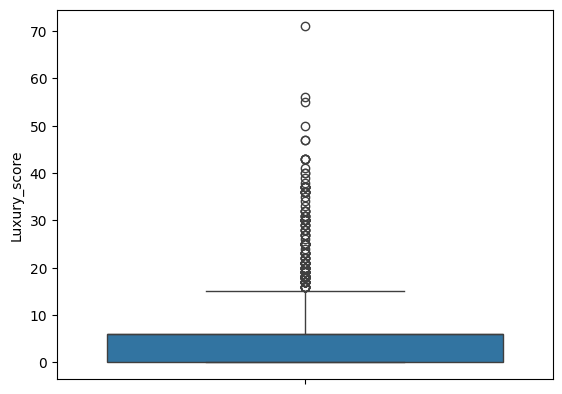

In [12]:
sns.boxplot(df['Luxury_score'])

In [13]:
 def categorize_luxury(score):
     if 0 <= score < 10:
         return 'Low'
     elif 10<= score < 20:
         return 'Medium'
     elif 20<= score < 35:
         return 'High'
     elif score > 35:
         return 'Very High'
     else:
         None

In [14]:
train_df['Luxury_category'] = train_df['Luxury_score'].apply(categorize_luxury)

In [15]:
train_df.sample(10)

,per_sqft,bedroom,bathroom,configuration,area,area_type,floor_number,facing,age_possession,property_type,price_cr,Luxury_score,sector_encoded,Luxury_category
639,17933.0,3,3,3,1500.0,Carpet,24.0,Unknown,Ready To Move,Flat,2.69,25,2.667327,High
1035,12601.0,2,2,2,865.0,Super Built-up,0.0,Unknown,Ready To Move,Flat,1.09,0,1.797143,Low
1710,42593.0,3,2,3,540.0,Super Built-up,0.0,Unknown,RESALE,House,2.30,6,2.300000,Low
701,10391.0,3,4,3,1790.0,Super Built-up,18.0,Unknown,Ready To Move,Flat,1.86,0,5.451622,Low
1119,14324.0,3,3,3,1850.0,Super Built-up,0.0,East,Ready To Move,Flat,2.65,6,3.154516,Low
2642,15484.0,10,8,10,4843.0,Covered,0.0,North,RESALE,House,7.50,18,5.243333,Medium
135,12001.0,3,4,3,2408.0,Super Built-up,8.0,East,Ready To Move,Flat,2.89,0,2.713056,Low
744,11111.0,3,3,3,1494.0,Super Built-up,4.0,East,Ready To Move,Flat,1.66,0,1.780870,Low
2330,22222.0,6,6,6,2025.0,Super Built-up,0.0,Unknown,RESALE,House,4.50,0,4.971429,Low
2614,15984.0,3,2,3,783.0,Super Built-up,0.0,Unknown,RESALE,House,1.25,6,1.207143,Low


# Floor Number

<Axes: ylabel='floor_number'>

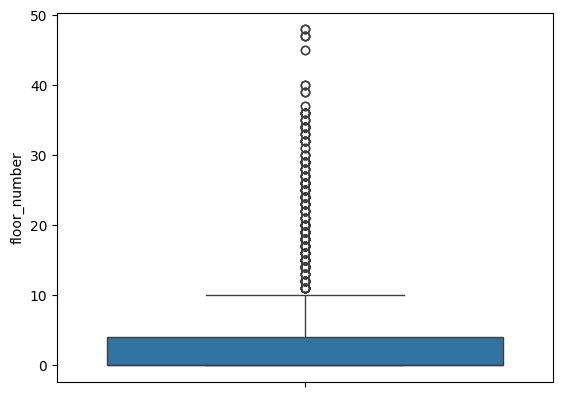

In [16]:
sns.boxplot(df['floor_number'])

In [17]:
def catogorize_floor(floor):
    if 0<= floor <= 2:
        return 'Low Floor'
    elif 3<= floor <= 10:
        return 'Mid Floor'
    elif floor > 10:
        return 'High Floor'
    else:
        return None

In [18]:
train_df['Floor_category'] = train_df['floor_number'].apply(catogorize_floor)

In [19]:
train_df.head()

,per_sqft,bedroom,bathroom,configuration,area,area_type,floor_number,facing,age_possession,property_type,price_cr,Luxury_score,sector_encoded,Luxury_category,Floor_category
0,14740.0,2,2,2,1099.0,Super Built-up,26.0,North-East,Ready To Move,Flat,1.62,6,2.838395,Low,High Floor
1,9010.0,4,4,4,1848.0,Super Built-up,0.0,West,Ready To Move,Flat,1.67,0,1.740714,Low,Low Floor
2,30167.0,4,4,4,5138.0,Carpet,0.0,North,Ready To Move,Flat,15.50,0,9.437500,Low,Low Floor
3,9714.0,3,3,3,1750.0,Built-up,0.0,East,Under Construction,Flat,1.70,12,1.780870,Medium,Low Floor
4,12063.0,4,4,4,3150.0,Super Built-up,0.0,Unknown,Ready To Move,Flat,3.80,0,2.838395,Low,Low Floor


In [20]:
train_df.drop(columns=['floor_number','Luxury_score'],inplace=True)

In [21]:
train_df.drop(columns = ['per_sqft'],inplace=True)

In [22]:
train_df.head()

,bedroom,bathroom,configuration,area,area_type,facing,age_possession,property_type,price_cr,sector_encoded,Luxury_category,Floor_category
0,2,2,2,1099.0,Super Built-up,North-East,Ready To Move,Flat,1.62,2.838395,Low,High Floor
1,4,4,4,1848.0,Super Built-up,West,Ready To Move,Flat,1.67,1.740714,Low,Low Floor
2,4,4,4,5138.0,Carpet,North,Ready To Move,Flat,15.50,9.437500,Low,Low Floor
3,3,3,3,1750.0,Built-up,East,Under Construction,Flat,1.70,1.780870,Medium,Low Floor
4,4,4,4,3150.0,Super Built-up,Unknown,Ready To Move,Flat,3.80,2.838395,Low,Low Floor


# label Encoding

In [23]:
from sklearn.preprocessing import OrdinalEncoder

In [24]:
# creating a copy of origianl data for encoding 
data_label_encoder = train_df.copy()

In [25]:
cat_cols = train_df.select_dtypes(include= ['object']).columns

In [26]:
# applying label encoding
for col in cat_cols:
    oe = OrdinalEncoder()
    data_label_encoder[col] = oe.fit_transform(data_label_encoder[[col]])
    print(oe.categories_)

[array(['Built-up', 'Carpet', 'Covered', 'Super Built-up'], dtype=object)]
[array(['East', 'North', 'North-East', 'South', 'South-East', 'South-West',
       'Unknown', 'West'], dtype=object)]
[array(['RESALE', 'Ready To Move', 'Under Construction'], dtype=object)]
[array(['Flat', 'House'], dtype=object)]
[array(['High', 'Low', 'Medium', 'Very High', None], dtype=object)]
[array(['High Floor', 'Low Floor', 'Mid Floor'], dtype=object)]


In [27]:
x_label = data_label_encoder.drop('price_cr',axis=1)
y_label = data_label_encoder['price_cr']

# Feature Selection 

## Technique 1 - Correlation Analyisis

<Axes: >

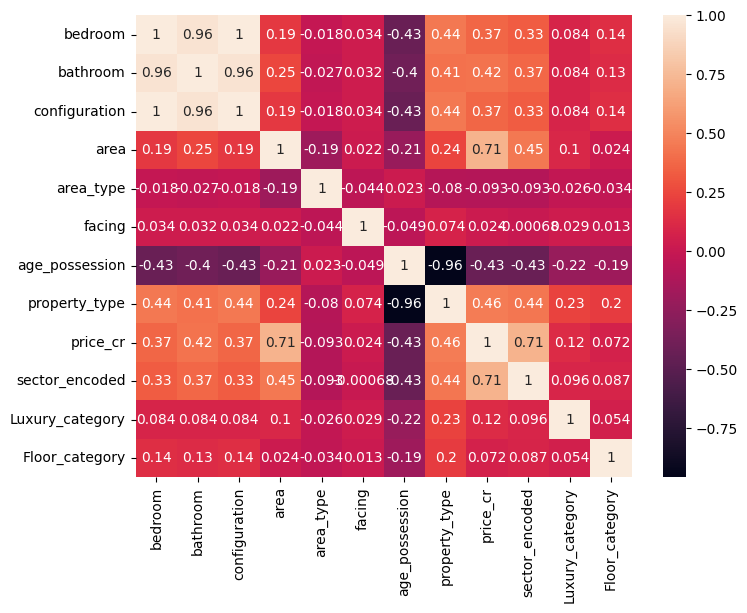

In [29]:
plt.figure(figsize=(8,6))
sns.heatmap(data_label_encoder.corr(),annot=True)

In [30]:
Feature_Importance_corr = data_label_encoder.corr()['price_cr'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price_cr':'corr_coef'})

## Technique 2 - Random Forest Feature Importance 

In [31]:
from sklearn.ensemble import RandomForestRegressor

In [32]:
rf = RandomForestRegressor(n_estimators=100,random_state=42)

In [33]:
rf.fit(x_label,y_label)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
Feature_Importance_RF = pd.DataFrame({'feature':x_label.columns,
                                  'rf_importance':rf.feature_importances_}).sort_values(by='rf_importance',ascending=False)

In [35]:
Feature_Importance_RF

,feature,rf_importance
3,area,0.592478
8,sector_encoded,0.266314
1,bathroom,0.037612
0,bedroom,0.024715
7,property_type,0.020926
2,configuration,0.018517
4,area_type,0.014943
5,facing,0.009787
6,age_possession,0.007214
9,Luxury_category,0.005320


# Technique 3 - Gradient Boosting Feature Importance 

In [36]:
from sklearn.ensemble import GradientBoostingRegressor

In [37]:
gb = GradientBoostingRegressor()

In [38]:
gb.fit(x_label,y_label)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [39]:
Feature_Importance_gb = pd.DataFrame({'feature':x_label.columns,
                                  'gb_importance':gb.feature_importances_}).sort_values(by='gb_importance',ascending=False)

In [40]:
Feature_Importance_gb

,feature,gb_importance
3,area,0.615699
8,sector_encoded,0.267554
0,bedroom,0.025122
1,bathroom,0.022845
2,configuration,0.022529
7,property_type,0.020125
4,area_type,0.012513
6,age_possession,0.009470
5,facing,0.001630
9,Luxury_category,0.001293


# Technique 4 - Permutuation Importance

In [41]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

In [42]:
X_train_label , X_test_label , y_train_label , y_test_label = train_test_split(x_label,y_label,test_size=0.2,random_state=42)

In [43]:
rf_label = RandomForestRegressor(n_estimators=100,random_state=42)

In [44]:
rf_label.fit(X_train_label,y_train_label)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
perm_importance = permutation_importance(rf_label,X_test_label,y_test_label, n_repeats=30, random_state=42)

In [46]:
Feature_Importance_perm = pd.DataFrame({'feature' : x_label.columns,
                                       'permutation_importance': perm_importance.importances_mean
                                       }).sort_values(by='permutation_importance',ascending=False)

In [47]:
Feature_Importance_perm

,feature,permutation_importance
3,area,0.704832
8,sector_encoded,0.401384
7,property_type,0.035538
4,area_type,0.014055
6,age_possession,0.006258
5,facing,0.001850
10,Floor_category,0.001682
1,bathroom,0.001416
0,bedroom,0.001160
9,Luxury_category,0.000470


# Technique 5 - Lasso 

In [48]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

In [49]:
ss = StandardScaler()

In [50]:
x_scaled = ss.fit_transform(x_label)

In [51]:
lasso = Lasso(alpha=0.01,random_state=42)

In [52]:
lasso.fit(x_scaled,y_label)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


In [53]:
Feature_Importance_lasso = pd.DataFrame({'feature': x_label.columns,
                                        'lasso_coef': lasso.coef_
                                        }).sort_values(by='lasso_coef',ascending=False)

In [54]:
Feature_Importance_lasso

,feature,lasso_coef
3,area,3.098076
8,sector_encoded,2.604488
7,property_type,0.930347
1,bathroom,0.617039
4,area_type,0.308640
6,age_possession,0.129347
5,facing,0.012145
0,bedroom,0.000000
2,configuration,0.000000
9,Luxury_category,-0.002387


# Technique 6 = RFE

In [55]:
from sklearn.feature_selection import RFE

In [56]:
est = RandomForestRegressor()

In [57]:
selector_label = RFE(est,n_features_to_select=x_label.shape[1],step=1)

In [58]:
selector_label = selector_label.fit(x_label,y_label)

In [59]:
selector_feature = x_label.columns[selector_label.support_]

In [60]:
selector_coefficents = selector_label.estimator_.feature_importances_

In [61]:
Feature_Importance_RFE = pd.DataFrame({'feature': selector_feature,
                                        'rfe_coef': selector_coefficents
                                        }).sort_values(by='rfe_coef',ascending=False)

In [62]:
Feature_Importance_RFE

,feature,rfe_coef
3,area,0.596976
8,sector_encoded,0.262092
1,bathroom,0.032740
2,configuration,0.027772
0,bedroom,0.019708
7,property_type,0.016789
4,area_type,0.013959
6,age_possession,0.011668
5,facing,0.010160
9,Luxury_category,0.005254


# Technique 7 - Linear Regression Weights 

In [ ]:
# I should have done One hot encoding for LR but in we have 237 sectors if i do OneHot Encoding it will cause Curse of dimensionality

In [65]:
from sklearn.linear_model import LinearRegression

In [66]:
lr = LinearRegression()

In [67]:
lr.fit(x_scaled,y_label)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [68]:
Feature_Importance_LR = pd.DataFrame({'feature': x_label.columns,
                                        'lr_coef': lr.coef_
                                        }).sort_values(by='lr_coef',ascending=False)

In [69]:
Feature_Importance_LR

,feature,lr_coef
3,area,3.102510
8,sector_encoded,2.610078
7,property_type,1.203097
1,bathroom,0.649542
6,age_possession,0.399532
4,area_type,0.335448
5,facing,0.016862
0,bedroom,-0.014604
2,configuration,-0.014604
9,Luxury_category,-0.016796


# Technique 8- SHAP 

In [71]:
import shap

C:\Users\Jyoti\.conda\envs\streamlit_ds\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [72]:
rf_shap = RandomForestRegressor(n_estimators=100,random_state=42)

In [73]:
rf_shap.fit(x_label,y_label)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [74]:
# computeing the shap values 

In [75]:
explainer = shap.TreeExplainer(rf_shap)

In [76]:
shap_values = explainer.shap_values(x_label)

In [77]:
# Summing the absolute Shap values across all sample to get overall measure of feature importance 

In [78]:
shap_sum = np.abs(shap_values).mean(axis=0)

In [79]:
shap_sum

array([0.24480271, 0.24340051, 0.15387925, 2.83269973, 0.06931581,
       0.04955845, 0.2217248 , 0.50196421, 1.69749327, 0.03632385,
       0.01568114])

In [80]:
Feaure_Importance_shap = pd.DataFrame({'feature': x_label.columns,
                                      'Shap_score': shap_sum}).sort_values(by='Shap_score',ascending=False)

In [81]:
Feaure_Importance_shap

,feature,Shap_score
3,area,2.832700
8,sector_encoded,1.697493
7,property_type,0.501964
0,bedroom,0.244803
1,bathroom,0.243401
6,age_possession,0.221725
2,configuration,0.153879
4,area_type,0.069316
5,facing,0.049558
9,Luxury_category,0.036324


# Merging all the Results of Feature Selection Techniques

In [86]:
print(set(Feature_Importance_corr['feature']) -
      set(Feature_Importance_RF['feature']))

{'price_cr'}


In [87]:
final_feature_importance_df = (
    Feature_Importance_corr
    .merge(Feature_Importance_RF, on='feature', how='outer')
    .merge(Feature_Importance_gb, on='feature', how='outer')
    .merge(Feature_Importance_perm, on='feature', how='outer')
    .merge(Feature_Importance_lasso, on='feature', how='outer')
    .merge(Feature_Importance_RFE, on='feature', how='outer')
    .merge(Feature_Importance_LR, on='feature', how='outer')
    .merge(Feaure_Importance_shap, on='feature', how='outer')
)

In [89]:
# final_feature_importance_df = Feature_Importance_corr.merge(Feature_Importance_RF,on='feature').merge(Feature_Importance_gb,on='feature').merge(Feature_Importance_perm,on='feature').merge(Feature_Importance_lasso,on='feature').merge(Feature_Importance_RFE,on='feature').merge(Feature_Importance_LR,on='feature').merge(Feaure_Importance_shap,on='feature')




In [90]:
final_feature_importance_df

,feature,corr_coef,rf_importance,gb_importance,permutation_importance,lasso_coef,rfe_coef,lr_coef,Shap_score
0,Floor_category,0.072297,0.002172,0.001220,0.001682,-0.053799,0.002882,-0.064925,0.015681
1,Luxury_category,0.121431,0.005320,0.001293,0.000470,-0.002387,0.005254,-0.016796,0.036324
2,age_possession,-0.430929,0.007214,0.009470,0.006258,0.129347,0.011668,0.399532,0.221725
3,area,0.713177,0.592478,0.615699,0.704832,3.098076,0.596976,3.102510,2.832700
4,area_type,-0.092639,0.014943,0.012513,0.014055,0.308640,0.013959,0.335448,0.069316
5,bathroom,0.420479,0.037612,0.022845,0.001416,0.617039,0.032740,0.649542,0.243401
6,bedroom,NaN,0.024715,0.025122,0.001160,0.000000,0.019708,-0.014604,0.244803
7,configuration,0.371819,0.018517,0.022529,-0.001307,0.000000,0.027772,-0.014604,0.153879
8,facing,0.024342,0.009787,0.001630,0.001850,0.012145,0.010160,0.016862,0.049558
9,price_cr,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [91]:
# Normalize the score

In [94]:
final_feature_importance_df = final_feature_importance_df.set_index('feature')

In [95]:
df_abs = final_feature_importance_df.abs()

df_normalized = df_abs.divide(df_abs.sum(axis=0), axis=1)

In [96]:
df_normalized[['corr_coef','rf_importance','gb_importance','permutation_importance','lasso_coef','rfe_coef','lr_coef','Shap_score']].mean(axis=1).sort_values(ascending=False)

feature
area               0.475447
sector_encoded     0.278193
price_cr           0.226474
property_type      0.067131
bathroom           0.048297
age_possession     0.028991
configuration      0.022655
area_type          0.020678
bedroom            0.016089
Luxury_category    0.006007
Floor_category     0.005164
facing             0.005051
dtype: float64

In [ ]:
# here i can see that Floor_category ,facing and Luxury_category  are not that important

In [ ]:
# So first lets train a model with all columns 

In [97]:
from sklearn.model_selection import cross_val_score

In [98]:
rf_all_col = RandomForestRegressor(n_estimators=100,random_state=42)

In [99]:
scores = cross_val_score(rf_all_col,x_label,y_label,cv=5,scoring='r2')

In [100]:
scores.mean()

0.8302661980366214

In [101]:
 # lets drop Floor_category, facing and Luxury_category

In [102]:
rf_dropped = RandomForestRegressor(n_estimators=100,random_state=42)

In [103]:
scores_dropped = cross_val_score(rf_dropped,x_label.drop(columns=['Floor_category','facing','Luxury_category']),y_label,cv=5,scoring='r2')

In [104]:
scores_dropped.mean()

0.8329338417347824

In [105]:
export_df = x_label.drop(columns=['Floor_category','facing','Luxury_category'])

In [106]:
export_df['price'] = y_label

In [107]:
export_df.head()

,bedroom,bathroom,configuration,area,area_type,age_possession,property_type,sector_encoded,price
0,2,2,2,1099.0,3.0,1.0,0.0,2.838395,1.62
1,4,4,4,1848.0,3.0,1.0,0.0,1.740714,1.67
2,4,4,4,5138.0,1.0,1.0,0.0,9.437500,15.50
3,3,3,3,1750.0,0.0,2.0,0.0,1.780870,1.70
4,4,4,4,3150.0,3.0,1.0,0.0,2.838395,3.80


In [108]:
export_df.to_csv('Gurgaon_Properties_Feature_selection.csv')